##**UBER RIDE ANALYSIS**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [ ]:
path = 'https://gitlab.crio.do/me_notebook/me_jupyter_uberanalysis/-/raw/master/Uber_ride_analysis_dataset.csv'
df = pd.read_csv(path,header=0)
df.head()

,Request id,Pickup point,Drop point,Request timestamp,Start timestamp,Drop timestamp,Trip Cost,Extra Tip,Driver id,Trip Status,Ride Type,Payment Method,Weather
0,4386.0,Majestic Bus Station,Bangalore Palace,2021-07-13 0:00:24,NaN,NaN,0.00,0.0,61.0,Trip Cancelled,UberXL,NaN,Clear
1,4387.0,Lalbagh Botanical Garden,Indiranagar,2021-07-13 0:02:14,2021-07-13 0:16:00,2021-07-13 0:26:14,111.38,0.0,17.0,Trip Completed,UberGo,Cash,Cloudy
2,4388.0,Lalbagh Botanical Garden,Kormangala Police Station,2021-07-13 0:06:34,2021-07-13 0:14:01,2021-07-13 2:01:34,89.00,25.0,21.0,Trip Completed,UberXL,Card,Clear
3,4389.0,Majestic Bus Station,ISKCON Temple,2021-07-13 0:07:31,NaN,NaN,0.00,0.0,NaN,No Cars Available,UberXL,NaN,Rainy
4,4390.0,Bangalore City Railway Station,Lalbagh Botanical Garden,2021-07-13 0:07:58,2021-07-13 0:20:21,2021-07-13 0:40:58,307.40,25.0,35.0,Trip Completed,UberGo,Cash,Rainy


###**DATA CLEANING**


To ensure consistency and ease of access, all column names are converted to lowercase and spaces are replaced with underscores. This standardization simplifies data manipulation and querying.

In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['request_id', 'pickup_point', 'drop_point', 'request_timestamp',
       'start_timestamp', 'drop_timestamp', 'trip_cost', 'extra_tip',
       'driver_id', 'trip_status', 'ride_type', 'payment_method', 'weather'],
      dtype='object')


Checking for null values is a critical first step in data cleaning. It helps identify which columns have missing data and quantify the extent of these missing values, guiding subsequent imputation or removal strategies.

In [ ]:
df.isnull().sum()


,0
request_id,200
pickup_point,200
drop_point,200
request_timestamp,200
start_timestamp,1850
drop_timestamp,1850
trip_cost,200
extra_tip,200
driver_id,975
trip_status,200



Missing values are handled to maintain data integrity and prevent errors in analysis. Rows with missing `trip_status` or `trip_cost` are dropped as these are crucial for analysis. `payment_method` nulls are filled with the mode, and `driver_id` nulls are set to -1 to signify an unassigned driver, which is important for identifying 'No Cars Available' scenarios. Lastly, incomplete 'Trip Completed' entries (missing `start_timestamp` or `drop_timestamp`) are removed to ensure data quality for completed trips.

In [ ]:
df.dropna(subset = ['trip_status', 'trip_cost'], inplace = True)
df.fillna({'payment_method' : df['payment_method'].mode()[0]}, inplace = True)
df.fillna({'driver_id' : -1}, inplace = True)
df = df[~((df['trip_status'] == 'Trip Completed') & (df['start_timestamp'].isna() | df['drop_timestamp'].isna()))]


Re-checking for null values after the initial cleaning steps confirms that the missing data has been addressed as intended and provides an updated overview of the DataFrame's completeness.

In [ ]:
df.isnull().sum()

,0
request_id,0
pickup_point,0
drop_point,0
request_timestamp,0
start_timestamp,1650
drop_timestamp,1650
trip_cost,0
extra_tip,0
driver_id,0
trip_status,0



Converting timestamp columns to datetime objects is essential for performing time-based calculations (like trip duration or delay) and extracting temporal components such as date, day of the week, or hour, which are crucial for trend analysis.

In [ ]:
date_columns = ['request_timestamp', 'start_timestamp', 'drop_timestamp']
for col in date_columns:
  df[col] = pd.to_datetime(df[col])



Identifying numeric columns allows for easy selection when performing numerical operations, such as statistical aggregations or outlier detection, without affecting non-numeric data.

In [ ]:
numeric_columns = df.select_dtypes(include = 'number').columns.to_list()
numeric_columns

['request_id', 'trip_cost', 'extra_tip', 'driver_id']

###**OUTLIER DETECTION AND TREATMENT**


A box plot is used to visualize the distribution of `trip_cost` and identify any potential outliers. Outliers can skew statistical analyses, so understanding their presence is important before treatment.

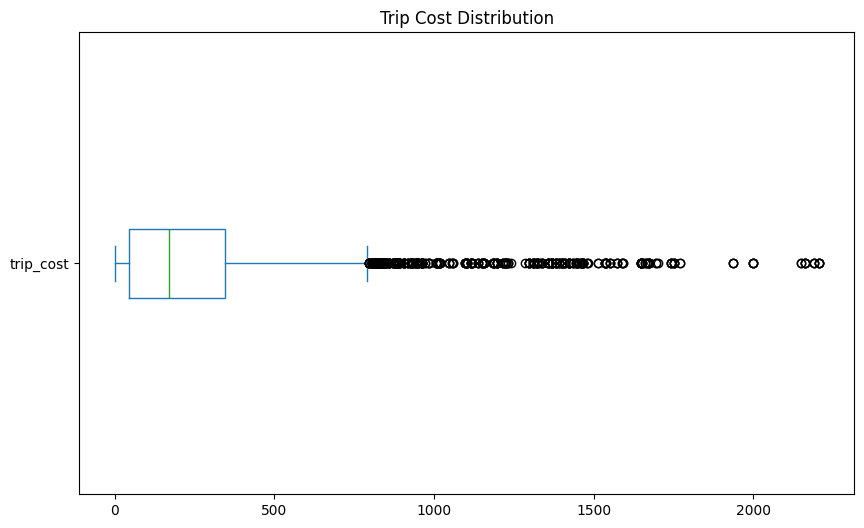

In [ ]:
os.makedirs('outputs/charts/', exist_ok=True)
plt.figure(figsize=(10, 6))
df['trip_cost'].plot(kind='box', vert = False)
plt.title("Trip Cost Distribution")
plt.savefig("outputs/charts/Trip Cost Distribution.png")
plt.show()


The Interquartile Range (IQR) method is applied to cap outliers in `trip_cost`. This technique replaces values beyond 1.5 times the IQR from the first (Q1) and third (Q3) quartiles with the respective bounds, mitigating the influence of extreme values on the dataset's distribution.

In [ ]:
Q1 = df['trip_cost'].quantile(0.25)
Q3 = df['trip_cost'].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5*IQR
df['trip_cost'] = np.where(df['trip_cost'] > upper_bound, upper_bound, df['trip_cost'])
lower_bound = Q1 - 1.5*IQR
df['trip_cost'] = np.where(df['trip_cost'] < lower_bound, lower_bound, df['trip_cost'])



Re-plotting the `trip_cost` distribution after outlier treatment confirms that the capping method has effectively reduced the impact of extreme values, leading to a more normalized and robust distribution for further analysis.

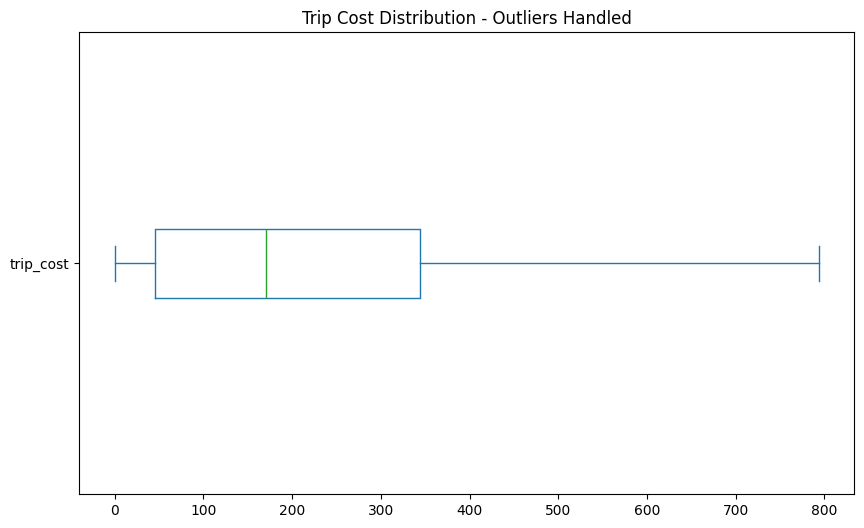

In [ ]:
plt.figure(figsize=(10, 6))
df['trip_cost'].plot(kind='box', vert = False)
plt.title("Trip Cost Distribution - Outliers Handled")
plt.savefig("outputs/charts/Trip Cost Distribution - Outliers Handled.png")
plt.show()


Similar to `trip_cost`, a box plot for `extra_tip` is generated to visualize its distribution and identify any outliers. This helps in understanding the spread of additional payments before any necessary adjustments.

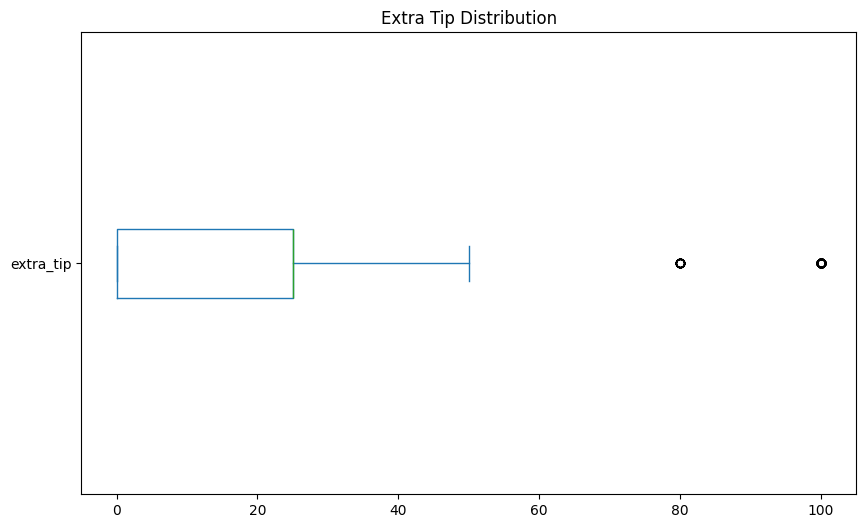

In [ ]:
plt.figure(figsize=(10, 6))
df['extra_tip'].plot(kind='box', vert = False)
plt.title("Extra Tip Distribution")
plt.savefig("outputs/charts/Extra Tip Distribution.png")
plt.show()


Outliers in `extra_tip` are treated using the IQR method. Capping these extreme values ensures that statistical analyses involving tips are not unduly influenced by a few exceptionally high or low values.

In [ ]:

Q1 = df['extra_tip'].quantile(0.25)
Q3 = df['extra_tip'].quantile(0.75)
IQR = Q3- Q1

upper_bound = Q3 + 1.5*IQR
df['extra_tip'] = np.where(df['extra_tip'] > upper_bound, upper_bound, df['extra_tip'])
lower_bound = Q1 - 1.5*IQR
df['extra_tip'] = np.where(df['extra_tip'] < lower_bound, lower_bound, df['extra_tip'])



After treating outliers in `extra_tip`, this box plot confirms the effectiveness of the capping, showing a more consolidated distribution of extra tip amounts.

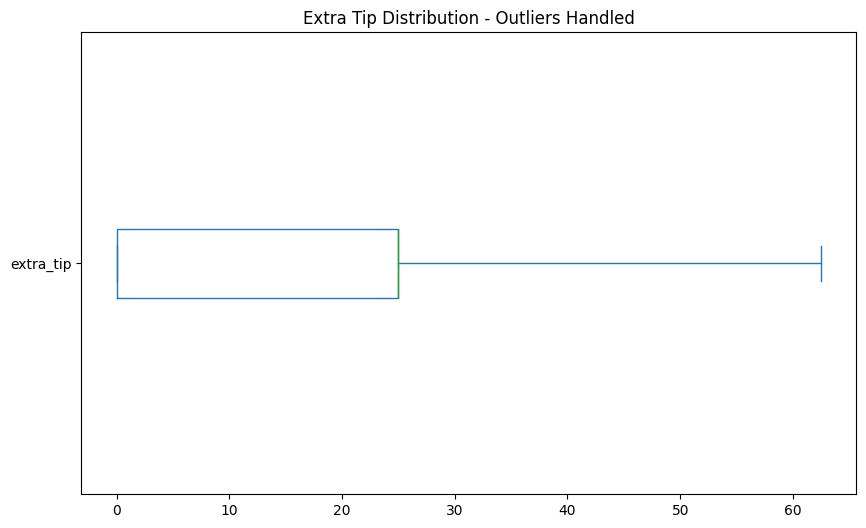

In [ ]:
#Extra Tip After Outliers Handled
plt.figure(figsize=(10, 6))
df['extra_tip'].plot(kind='box', vert = False)
plt.title("Extra Tip Distribution - Outliers Handled")
plt.savefig("outputs/charts/Extra Tip Distribution - Outliers Handled.png")
plt.show()

###**EXPLORATORY DATA ANALYSIS (EDA)**


Displaying the shape of the DataFrame (number of rows and columns) provides a quick overview of the dataset's size and structure after cleaning and preprocessing. It's a fundamental step to confirm the data dimensions.

In [ ]:
df.shape

(6745, 13)

In [ ]:
df.dtypes

,0
request_id,float64
pickup_point,object
drop_point,object
request_timestamp,datetime64[ns]
start_timestamp,datetime64[ns]
drop_timestamp,datetime64[ns]
trip_cost,float64
extra_tip,float64
driver_id,float64
trip_status,object



This bar plot visualizes the breakdown of trip statuses. Understanding the proportion of 'Trip Completed', 'Trip Cancelled', and 'No Cars Available' is fundamental to assessing the overall efficiency and common issues within the ride service.

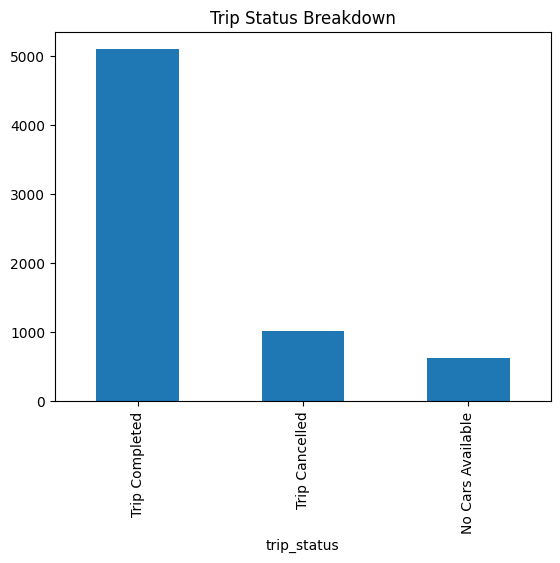

In [ ]:
#Trip Status Breakdown
df['trip_status'].value_counts().plot(kind = 'bar')
plt.title("Trip Status Breakdown")
plt.savefig("outputs/charts/Trip Status Breakdown.png")
plt.show()


A histogram of `trip_cost` is generated to visualize its distribution. This helps in understanding the most frequent trip costs, the range of costs, and identifying any patterns or unusual concentrations within the pricing.

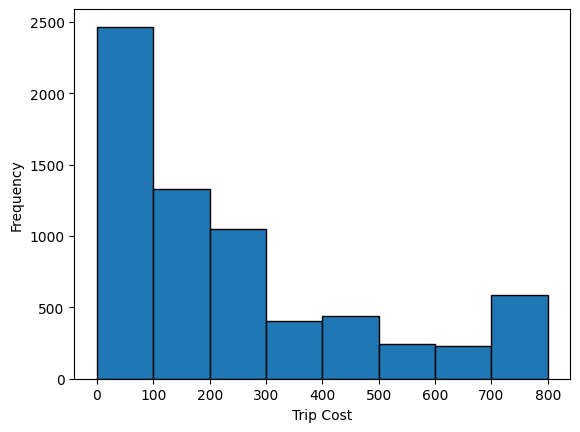

In [ ]:
#Trip Cost Distribution
max_cost = df['trip_cost'].max()
bins = np.arange(0, max_cost + 100, 100)
df['trip_cost'].hist(bins = bins, edgecolor = 'black')
plt.xlabel('Trip Cost')
plt.ylabel('Frequency')
plt.grid(False)
plt.savefig("outputs/charts/Trip Cost Distribution.png")
plt.show()


Aggregating `trip_cost` by `payment_method` to calculate the mean, median, and count provides insights into the financial characteristics and usage patterns associated with each payment option. This helps assess the effectiveness and preferences for different payment methods.

In [ ]:
#Analyze Payment Methods
df.groupby('payment_method')['trip_cost'].agg(['mean','median','count']).sort_values(by = 'mean', ascending = False)

,mean,median,count
payment_method,,,
Card,316.517799,231.50,1708
UPI,315.056717,233.75,1663
Cash,156.880047,45.00,3374



Calculating `trip_duration_minutes` is essential for understanding the length of completed journeys. This metric is important for assessing service efficiency, rider experience, and could be correlated with trip cost or driver earnings.

In [ ]:
df['trip_duration_minutes'] = (df['drop_timestamp'] - df['start_timestamp']).dt.total_seconds() / 60


A histogram for `trip_duration_minutes` helps visualize the distribution of ride lengths. This can reveal common trip durations, peak duration ranges, and potential outliers in trip times.

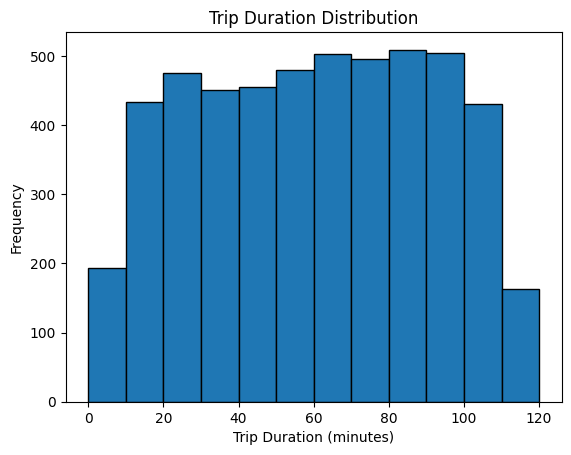

In [ ]:
max_duration = df['trip_duration_minutes'].max()
bins = np.arange(0, max_duration + 10, 10)
df['trip_duration_minutes'].hist(bins = bins, edgecolor = 'black')
plt.title('Trip Duration Distribution')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Frequency')
plt.grid(False)
plt.savefig("outputs/charts/Trip Duration Distribution.png")
plt.show()

###**TRANSFORMING DATA**

In [ ]:
df.columns

Index(['request_id', 'pickup_point', 'drop_point', 'request_timestamp',
       'start_timestamp', 'drop_timestamp', 'trip_cost', 'extra_tip',
       'driver_id', 'trip_status', 'ride_type', 'payment_method', 'weather',
       'trip_duration_minutes'],
      dtype='object')


Creating a `total_cost` column by summing `trip_cost` and `extra_tip` provides a comprehensive view of the total amount a rider pays for a trip, which is a more complete metric for financial analysis.

In [ ]:
#Total Trip Cost
df['total_cost'] = df['trip_cost'] + df['extra_tip']



Extracting granular time components such as date, day name, and hour from timestamp columns allows for detailed time-series analysis. This enables investigation into daily, weekly, and hourly patterns of requests, starts, and drops, which are crucial for operational planning.

In [ ]:
#Converting Time to DateTime Columns
df['request_timestamp'] = pd.to_datetime(df['request_timestamp'])
df['start_timestamp'] = pd.to_datetime(df['start_timestamp'])
df['drop_timestamp'] = pd.to_datetime(df['drop_timestamp'])

In [ ]:
#Extract Date and Time Components
df['request_date'] = df['request_timestamp'].dt.date
df['start_date'] = df['start_timestamp'].dt.date
df['drop_date'] = df['drop_timestamp'].dt.date

df['request_day'] = df['request_timestamp'].dt.day_name()
df['start_day'] = df['start_timestamp'].dt.day_name()
df['drop_day'] = df['drop_timestamp'].dt.day_name()

df['request_time'] = df['request_timestamp'].dt.time
df['start_time'] = df['start_timestamp'].dt.time
df['drop_time'] = df['drop_timestamp'].dt.time

df['request_hour'] = df['request_timestamp'].dt.hour
df['start_hour'] = df['start_timestamp'].dt.hour
df['drop_hour'] = df['drop_timestamp'].dt.hour


Calculating `ride_delay` as the difference between `start_timestamp` and `request_timestamp` helps quantify the waiting time for riders. This metric is vital for evaluating service responsiveness and identifying potential areas for improvement in driver assignment or availability.

In [ ]:
#Calculating the Ride Delay
df['ride_delay'] = ((df['start_timestamp'] - df['request_timestamp']).dt.total_seconds() / 3600).round(2)


Categorizing `cancellation_reason` into 'No Cabs', 'Passenger', or 'Driver' provides clarity on who initiated the cancellation or if it was due to unavailability. This classification is crucial for targeted interventions to reduce cancellation rates.

In [ ]:
#Cancellation Reason
df['cancellation_reason'] = np.where(
    (df['driver_id'] == -1) & (df['trip_status'] == 'No Cars Available'), 'No Cabs',
    np.where(
        (df['driver_id'] == -1) & (df['trip_status'] == 'Trip Cancelled'), 'Passenger',
        np.where(
            (df['driver_id'] != -1) & (df['trip_status'] == 'Trip Cancelled'), 'Driver',
            'Trip Completed'
        )
    )
)

###ANALYSIS


This count plot visualizes the number of ride requests across different days of the week. It helps identify which days experience the highest and lowest demand, aiding in resource allocation and strategic planning.

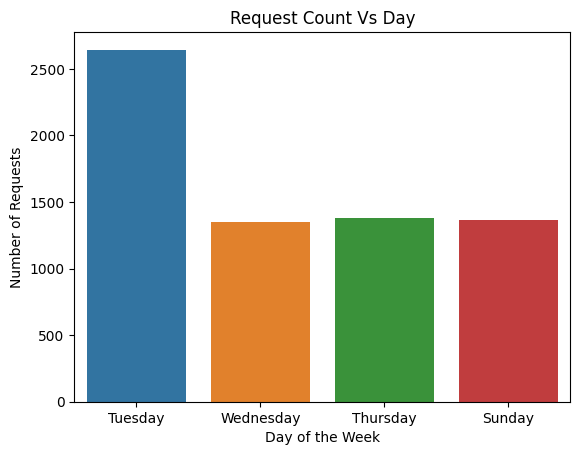

In [ ]:
import seaborn as sns
sns.countplot(data = df, x = 'request_day', hue = 'request_day', legend = False)
plt.title("Request Count Vs Day")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Requests")
plt.savefig("outputs/charts/Request Day Distribution.png")
plt.show()


This count plot illustrates the distribution of ride requests throughout the hours of the day. Identifying peak hours of demand is essential for dynamic pricing strategies, driver deployment, and managing service capacity effectively.

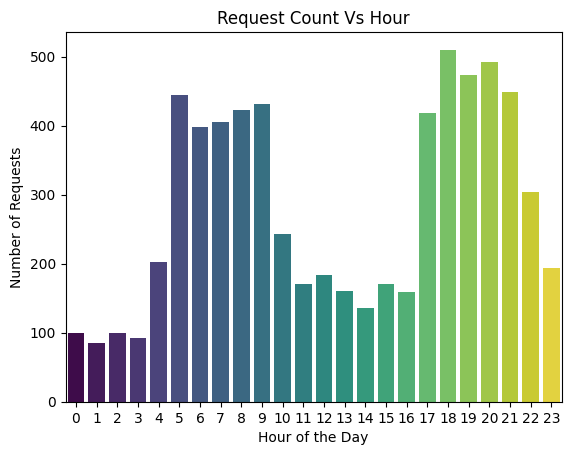

In [ ]:
sns.countplot(data = df, x = 'request_hour', hue = 'request_hour', palette='viridis', legend = False)
plt.title("Request Count Vs Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Requests")
plt.savefig("outputs/charts/Request Hour Distribution.png")
plt.show()


A pie chart is used to visually represent the overall proportion of each `trip_status`. This provides an immediate understanding of how many trips are completed, cancelled, or face 'no cars available' issues, highlighting the most prevalent outcomes.

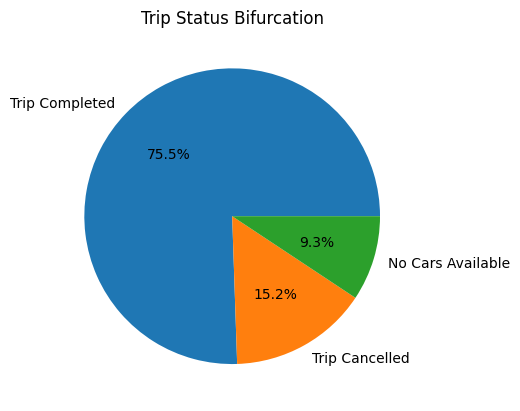

In [ ]:
trip_status_rates = df['trip_status'].value_counts(normalize = True)*100
plt.pie(trip_status_rates, labels = trip_status_rates.index, autopct= '%1.1f%%')
plt.title("Trip Status Bifurcation")
plt.savefig("outputs/charts/Trip Status Bifurcation.png")
plt.show()


Analyzing cancellation trends specifically for 'Trip Cancelled' statuses helps differentiate between driver-initiated and passenger-initiated cancellations. This distinction is crucial for understanding the underlying causes of cancellations and implementing targeted solutions.

Cancellation Trends (Driver vs Passenger):
cancellation_reason
Driver       875
Passenger    147
Name: count, dtype: int64


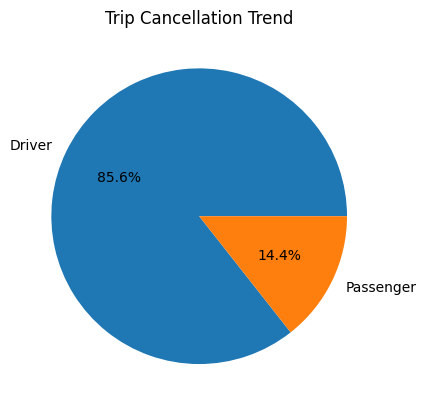

In [ ]:
cancellation_trends = df[df['trip_status'] == 'Trip Cancelled']['cancellation_reason'].value_counts()

print(f"Cancellation Trends (Driver vs Passenger):")
print(cancellation_trends)

plt.pie(cancellation_trends , labels = cancellation_trends.index, autopct = '%1.1f%%')

plt.title("Trip Cancellation Trend")
plt.show()


Filtering the DataFrame to create `incomplete_rides_df` and then visualizing its status distribution helps focus the analysis on problematic trips. Understanding the proportion of 'Trip Cancelled' versus 'No Cars Available' within incomplete rides can pinpoint key areas for operational improvement.

trip_status
Trip Cancelled       0.619394
No Cars Available    0.380606
Name: proportion, dtype: float64


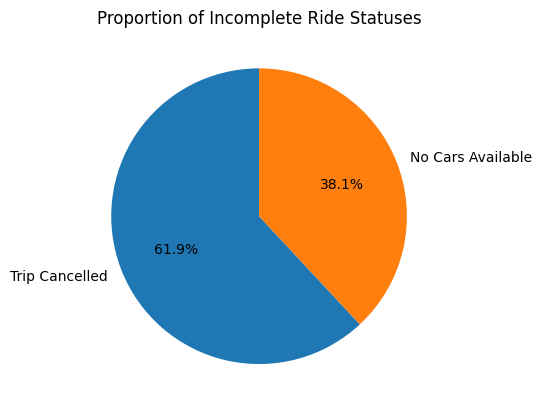

In [ ]:
incomplete_rides_df = df[df['trip_status'] != 'Trip Completed']
incomplete_rides_df = incomplete_rides_df[['request_id', 'pickup_point', 'drop_point', 'driver_id', 'trip_status', 'payment_method', 'weather', 'request_day', 'request_hour', 'cancellation_reason']]

status_count = incomplete_rides_df['trip_status'].value_counts(normalize = True)
print(status_count)
plt.pie(status_count, labels = status_count.index, autopct = '%1.1f%%', startangle = 90)
plt.title("Proportion of Incomplete Ride Statuses")
plt.savefig("outputs/charts/Proportion of Incomplete Ride Statuses.png")
plt.show()


This histogram visualizes incomplete rides broken down by the day of the week and `cancellation_reason`. It helps identify if specific days are more prone to certain types of cancellations (e.g., more driver cancellations on weekends), aiding in day-specific operational adjustments.

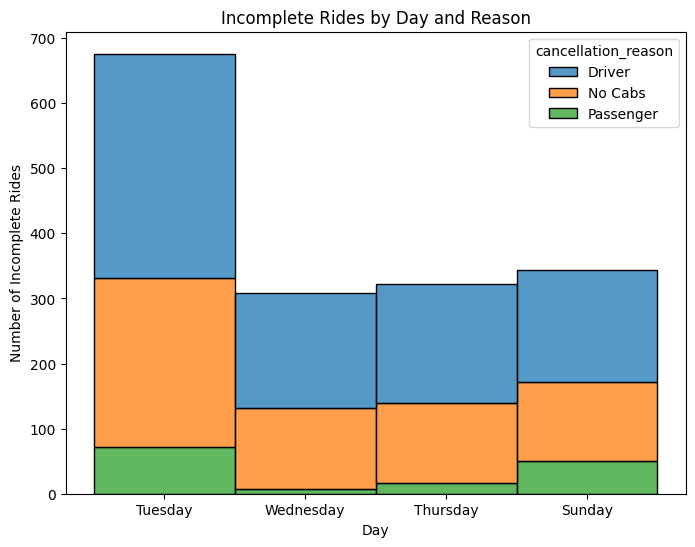

In [ ]:
plt.figure(figsize = (8,6))
sns.histplot(data = incomplete_rides_df, x = 'request_day', hue = 'cancellation_reason', bins = 7, multiple = "stack")
plt.title("Incomplete Rides by Day and Reason")
plt.xlabel("Day")
plt.ylabel("Number of Incomplete Rides")
plt.savefig("outputs/charts/Incomplete Rides by Day and Reason.png")
plt.show()


This histogram displays incomplete rides categorized by the hour of the day and `cancellation_reason`. Analyzing this helps pinpoint specific hours when cancellations, whether by drivers, passengers, or due to no cars, are most prevalent, allowing for time-sensitive operational adjustments.

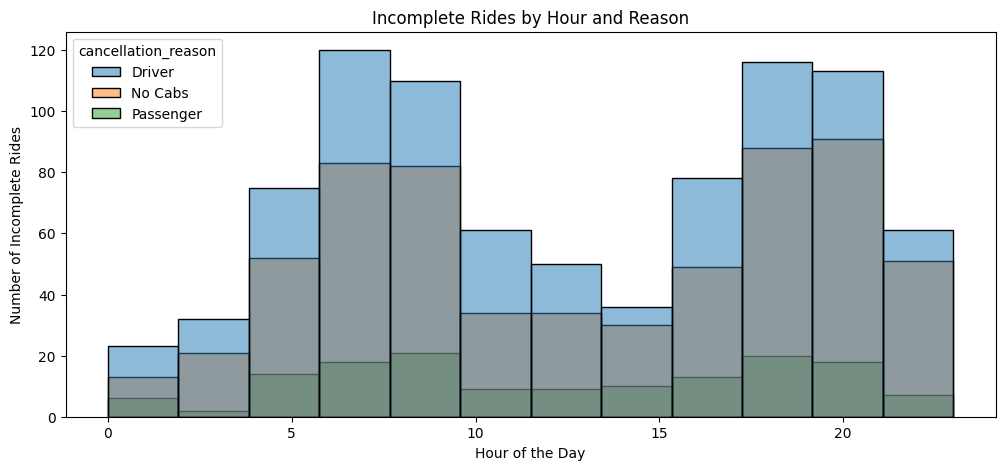

In [ ]:
plt.figure(figsize = (12,5))
sns.histplot(data = incomplete_rides_df, x = 'request_hour', hue = 'cancellation_reason')
plt.title("Incomplete Rides by Hour and Reason")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Incomplete Rides")
plt.savefig("outputs/charts/Incomplete Rides by Hour and Reason.png")
plt.show()


Grouping incomplete rides by `weather` and `cancellation_reason` and then visualizing them helps assess how different weather conditions influence various cancellation types. This can reveal if adverse weather leads to more driver cancellations or fewer cars available, informing contingency planning.


This bar plot specifically examines driver cancellations segmented by weather conditions. It helps to determine if certain weather patterns significantly impact a driver's decision to cancel a trip, providing actionable insights for driver incentives or support during inclement weather.

  weather cancellation_reason  count
0   Clear              Driver    288
1   Clear             No Cabs    199
2   Clear           Passenger     47
3  Cloudy              Driver    280
4  Cloudy             No Cabs    212
5  Cloudy           Passenger     45
6   Rainy              Driver    307
7   Rainy             No Cabs    217
8   Rainy           Passenger     55


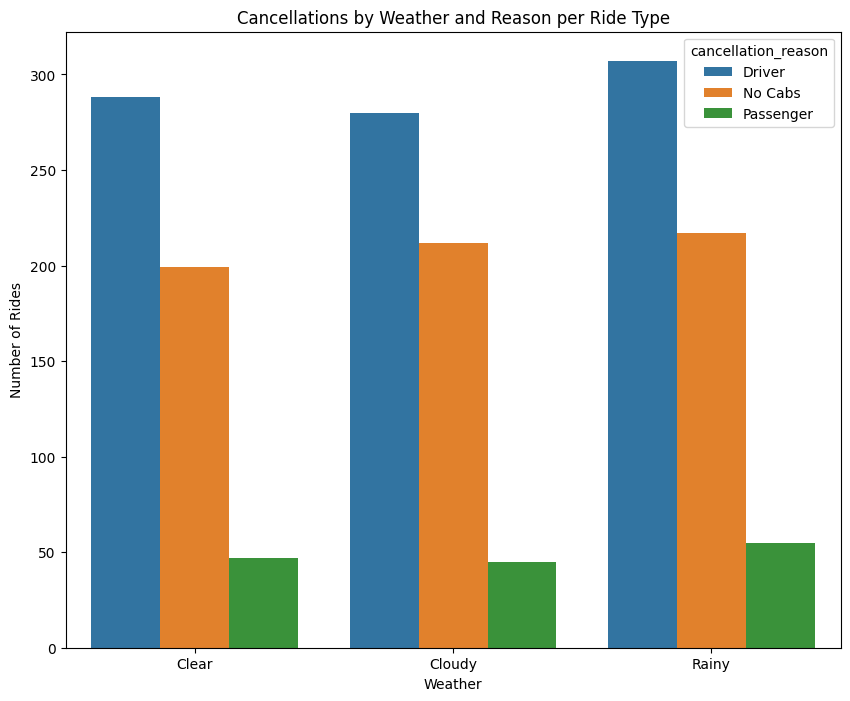

In [ ]:
final_group = incomplete_rides_df.groupby(['weather', 'cancellation_reason']).size().reset_index(name='count')
print(final_group)
plt.figure(figsize = (10,8))
sns.barplot(data = final_group, x = 'weather', y = 'count', hue = 'cancellation_reason')
plt.title("Cancellations by Weather and Reason per Ride Type")
plt.xlabel("Weather")
plt.ylabel("Number of Rides")
plt.savefig("outputs/charts/Cancellations by Weather and Reason per Ride Type.png")
plt.show()


Investigating how the calculated `ride_delay` affects trip outcomes. This can involve visualizing the distribution of `ride_delay` for completed trips versus cancelled trips, and potentially analyzing average delays by `pickup_point` or `request_hour` to identify common delay causes.



To investigate the impact of ride_delay on trip status, I will create a box plot visualizing the distribution of `ride_delay` across different `trip_status` categories.



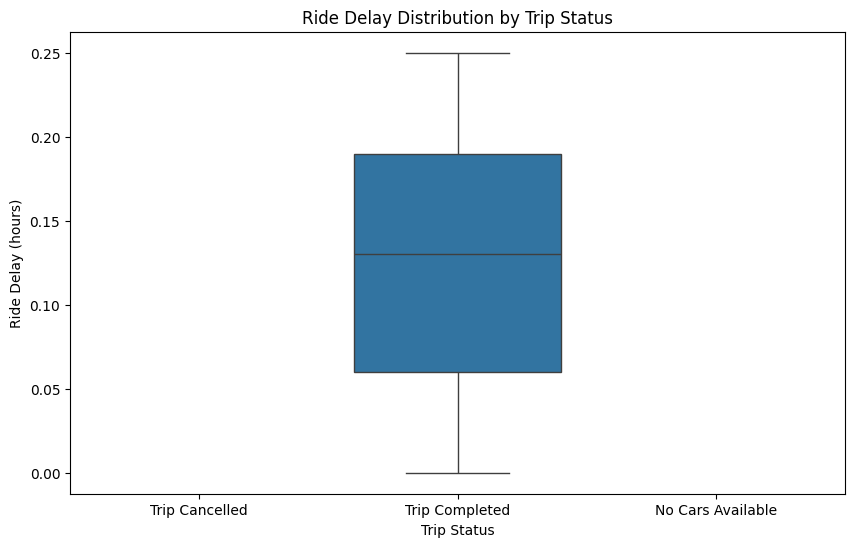

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='trip_status', y='ride_delay')
plt.title('Ride Delay Distribution by Trip Status')
plt.xlabel('Trip Status')
plt.ylabel('Ride Delay (hours)')
plt.savefig("outputs/charts/Ride Delay Impact on Trip Status.png")
plt.show()



To further investigate the impact of `ride_delay` on `trip_status`, I will calculate and display the mean and median `ride_delay` for each `trip_status` category.



In [ ]:
ride_delay_stats = df.groupby('trip_status')['ride_delay'].agg(['mean', 'median'])
print("Mean and Median Ride Delay by Trip Status:")
print(ride_delay_stats)

Mean and Median Ride Delay by Trip Status:
                       mean  median
trip_status                        
No Cars Available       NaN     NaN
Trip Cancelled          NaN     NaN
Trip Completed     0.125376    0.13



Analyzing the `incomplete_rides_df` to identify the top `pickup_point` and `drop_point` locations that contribute most to trip cancellations or 'No Cars Available' statuses. This will help in pinpointing areas where service improvements or increased driver availability might be needed.


To identify cancellation hotspots by `pickup_point`, I will first group the `incomplete_rides_df` by `pickup_point` and count the occurrences of each, then display the top 10 pickup points with the most incomplete rides.



In [ ]:
cancellation_hotspots_pickup = incomplete_rides_df['pickup_point'].value_counts().head(10)
print("Top 10 Cancellation Hotspots by Pickup Point:")
print(cancellation_hotspots_pickup)

Top 10 Cancellation Hotspots by Pickup Point:
pickup_point
Bangalore Palace             80
Phoenix Marketcity           77
Electronic City              76
Lalbagh Botanical Garden     75
Indiranagar                  74
Majestic Bus Station         73
Manyata Tech Park            73
Kormangala Police Station    72
ISKCON Temple                70
Embassy Tech Village         70
Name: count, dtype: int64


Identifying cancellation hotspots by `drop_point`, I will group the `incomplete_rides_df` by `drop_point` and count the occurrences, then display the top 10 drop points with the most incomplete rides, similar to how it was done for `pickup_point`.



In [ ]:
cancellation_hotspots_drop = incomplete_rides_df['drop_point'].value_counts().head(10)
print("Top 10 Cancellation Hotspots by Drop Point:")
print(cancellation_hotspots_drop)

Top 10 Cancellation Hotspots by Drop Point:
drop_point
HSR Layout                   88
Church Street                79
Koramangala Boho Street      78
Majestic Bus Station         78
ISKCON Temple                76
BTM Layout                   74
Indiranagar                  74
Cubbon Park                  74
Kormangala Police Station    73
Brigade Road                 73
Name: count, dtype: int64



Analyzing the distribution of `trip_status` for each `ride_type` to understand how different ride types (e.g., UberXL, UberGo) impact trip completion, cancellations, or availability. This will help identify if certain ride types are more prone to specific outcomes.


Analyzing the distribution of `trip_status` for each `ride_type`, I will first group the DataFrame by `ride_type` and `trip_status` to count occurrences, then display the results to identify any patterns.



In [ ]:
ride_type_outcomes = df.groupby(['ride_type', 'trip_status']).size().unstack(fill_value=0)
print("Trip Outcomes by Ride Type:")
print(ride_type_outcomes)

Trip Outcomes by Ride Type:
trip_status  No Cars Available  Trip Cancelled  Trip Completed
ride_type                                                     
UberGo                     217             335            1733
UberX                      193             346            1683
UberXL                     218             341            1679



To visually represent the distribution of trip statuses across different ride types, I will create a stacked bar chart using the `ride_type_outcomes` DataFrame generated in the previous step. This will provide a clear comparison of how each ride type impacts trip completion, cancellations, and availability.



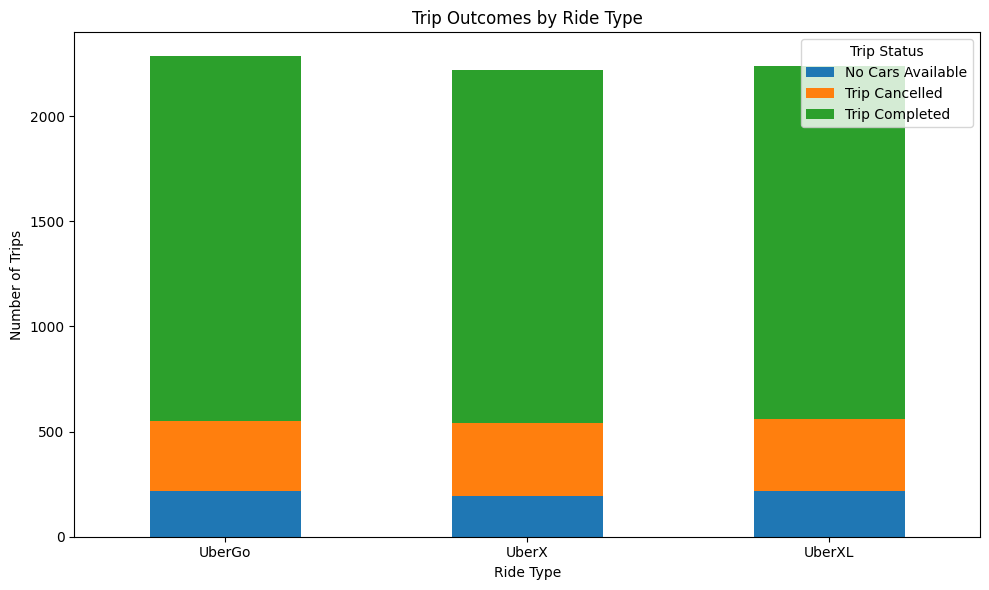

In [ ]:
ride_type_outcomes.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Trip Outcomes by Ride Type')
plt.xlabel('Ride Type')
plt.ylabel('Number of Trips')
plt.xticks(rotation=0)
plt.legend(title='Trip Status')
plt.tight_layout()
plt.savefig("outputs/charts/Trip Outcomes by Ride Type.png")
plt.show()


Investigating the effectiveness of different `payment_method` options by analyzing their correlation with `trip_status` and `trip_cost`. This analysis will help understand if certain payment methods are associated with higher completion rates, lower cancellation rates, or different average trip costs.


Analyzing the correlation between `payment_method` and `trip_status`, I will group the DataFrame by both columns and count the occurrences of each combination. This will reveal the distribution of trip statuses across different payment methods.



In [ ]:
payment_status_outcomes = df.groupby(['payment_method', 'trip_status']).size().unstack(fill_value=0)
print("Trip Outcomes by Payment Method:")
print(payment_status_outcomes)

Trip Outcomes by Payment Method:
trip_status     No Cars Available  Trip Cancelled  Trip Completed
payment_method                                                   
Card                            0               0            1708
Cash                          628            1022            1724
UPI                             0               0            1663



Calculating the mean of 'trip_cost' for each 'payment_method' in the DataFrame, and then create a bar plot to visualize these average trip costs, summarizing the findings to determine if certain payment methods are associated with higher or lower average trip costs.

In [ ]:
avg_trip_cost_by_payment = df.groupby('payment_method')['trip_cost'].mean()
print("Average Trip Cost by Payment Method:")
print(avg_trip_cost_by_payment)

Average Trip Cost by Payment Method:
payment_method
Card    316.517799
Cash    156.880047
UPI     315.056717
Name: trip_cost, dtype: float64



Now that the average trip cost by payment method has been calculated, I will create a bar plot to visualize these averages, which will help in understanding which payment methods are associated with higher or lower average trip costs.



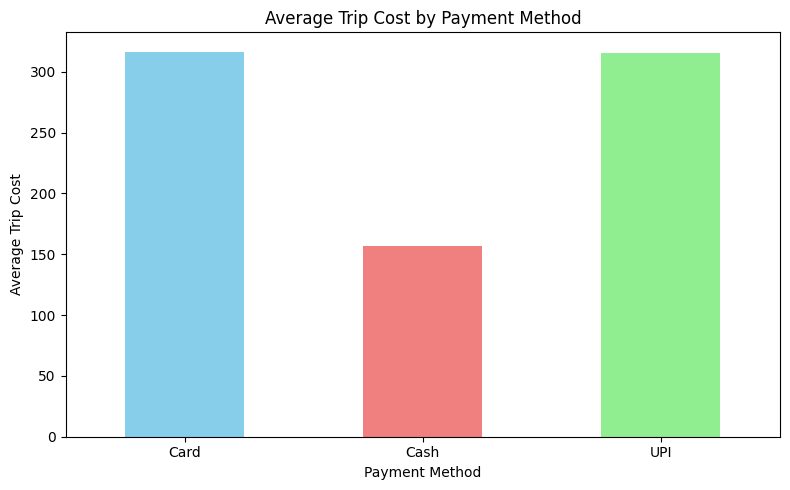

In [ ]:
plt.figure(figsize=(8, 5))
avg_trip_cost_by_payment.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Average Trip Cost by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Trip Cost')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/charts/Average Trip Cost by Payment Method.png")
plt.show()


Analyze driver cancellation patterns to understand when and why drivers tend to cancel trips. This involves examining the `cancellation_reason` and potentially `request_hour`, `request_day`, and `pickup_point` for trips where the driver is responsible for the cancellation.


To analyze driver cancellation patterns, I will first filter the `incomplete_rides_df` to only include trips where the `cancellation_reason` is 'Driver'. This will create a subset of data focused solely on driver-initiated cancellations.



In [ ]:
driver_cancellations_df = incomplete_rides_df[incomplete_rides_df['cancellation_reason'] == 'Driver']
print(f"Number of driver cancellations: {len(driver_cancellations_df)}")
driver_cancellations_df.head()

Number of driver cancellations: 875


,request_id,pickup_point,drop_point,driver_id,trip_status,payment_method,weather,request_day,request_hour,cancellation_reason
0,4386.0,Majestic Bus Station,Bangalore Palace,61.0,Trip Cancelled,Cash,Clear,Tuesday,0,Driver
9,4395.0,UB City,Lalbagh Botanical Garden,2.0,Trip Cancelled,Cash,Clear,Tuesday,0,Driver
14,4400.0,KR Puram Railway Station,Embassy Tech Village,69.0,Trip Cancelled,Cash,Clear,Tuesday,0,Driver
17,4403.0,BTM Layout,Orion Mall,94.0,Trip Cancelled,Cash,Cloudy,Tuesday,0,Driver
44,4430.0,Orion Mall,Koramangala Boho Street,97.0,Trip Cancelled,Cash,Rainy,Tuesday,2,Driver



To understand when drivers tend to cancel, I will analyze the distribution of driver cancellations by `request_hour`. This will help identify peak hours for driver cancellations.



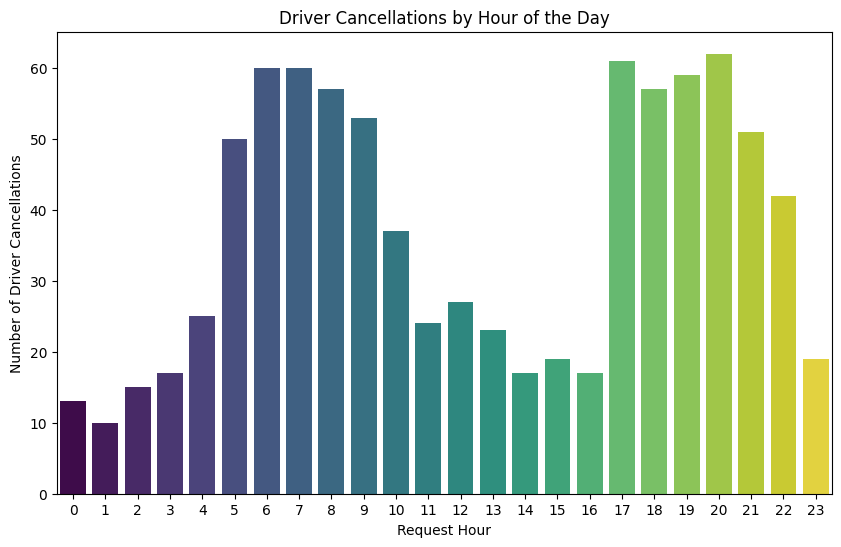

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=driver_cancellations_df, x='request_hour',hue = 'request_hour', legend = False, palette= 'viridis')
plt.title('Driver Cancellations by Hour of the Day')
plt.xlabel('Request Hour')
plt.ylabel('Number of Driver Cancellations')
plt.savefig("outputs/charts/Driver Cancellations by Hour.png")
plt.show()


To further understand driver cancellation patterns, I will analyze the distribution of driver cancellations by `request_day`. This will help identify if certain days of the week have higher rates of driver cancellations.



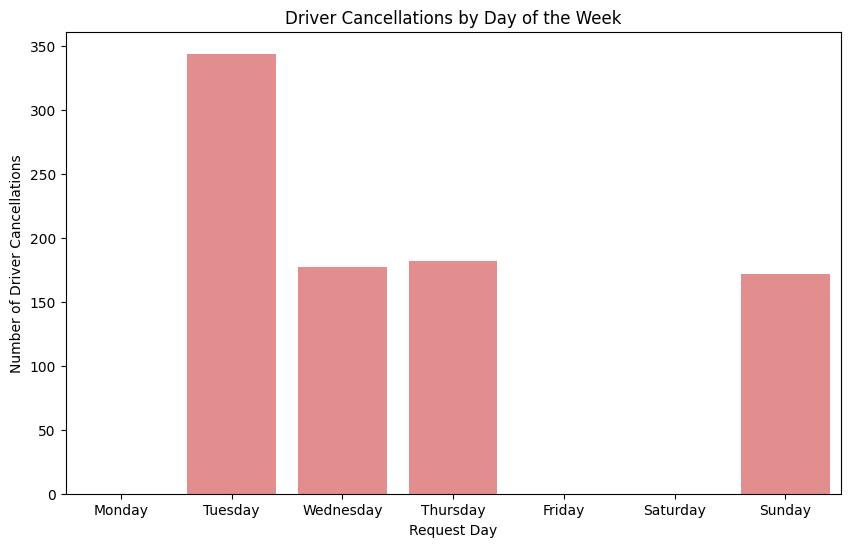

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=driver_cancellations_df, x='request_day', color='lightcoral', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Driver Cancellations by Day of the Week')
plt.xlabel('Request Day')
plt.ylabel('Number of Driver Cancellations')
plt.savefig("outputs/charts/Driver Cancellations by Day.png")
plt.show()


To further understand driver cancellation patterns, I will analyze the distribution of driver cancellations by `request_day`. This will help identify if certain days of the week have higher rates of driver cancellations.



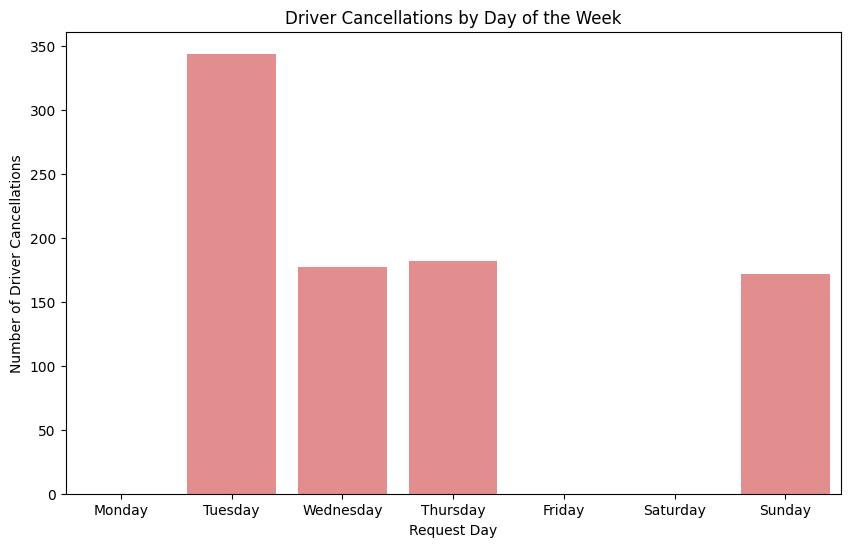

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=driver_cancellations_df, x='request_day', color='lightcoral', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Driver Cancellations by Day of the Week')
plt.xlabel('Request Day')
plt.ylabel('Number of Driver Cancellations')
plt.savefig("outputs/charts/Driver Cancellations by Day.png")
plt.show()


To identify specific locations where driver cancellations are most frequent, I will analyze the distribution of driver cancellations by `pickup_point`. This will help pinpoint problem areas.



In [ ]:
driver_cancellations_by_pickup = driver_cancellations_df['pickup_point'].value_counts().head(10)
print("Top 10 Pickup Points for Driver Cancellations:")
print(driver_cancellations_by_pickup)

Top 10 Pickup Points for Driver Cancellations:
pickup_point
Bangalore Palace             50
Phoenix Marketcity           44
Lalbagh Botanical Garden     43
Indiranagar                  43
Electronic City              42
Embassy Tech Village         42
Church Street                41
Kormangala Police Station    40
Brigade Road                 39
ISKCON Temple                38
Name: count, dtype: int64



To understand how weather conditions impact trip cost, I will first calculate the mean `trip_cost` for each `weather` category. This will provide a statistical overview of the average cost under different weather conditions.



In [ ]:
avg_trip_cost_by_weather = df.groupby('weather')['trip_cost'].mean()
print("Average Trip Cost by Weather Condition:")
print(avg_trip_cost_by_weather)

Average Trip Cost by Weather Condition:
weather
Clear     151.123668
Cloudy    150.481597
Rainy     401.649413
Name: trip_cost, dtype: float64


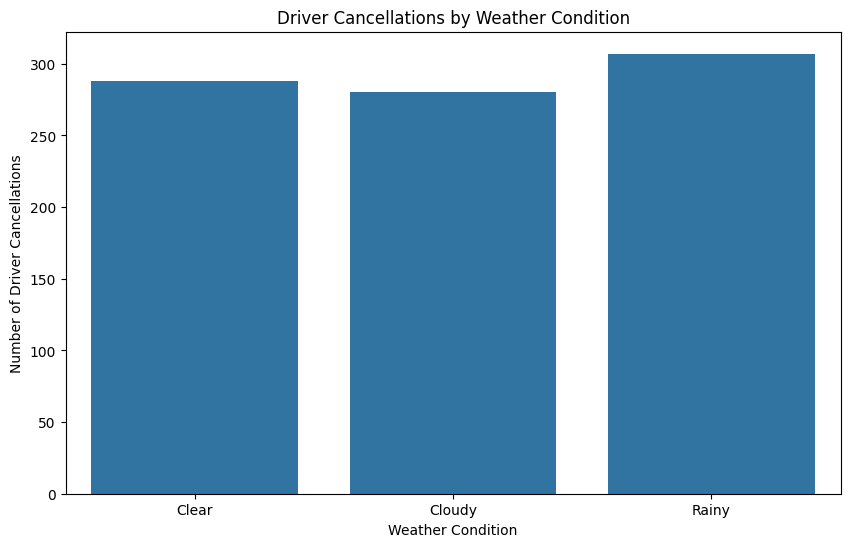

In [ ]:
driver_cancellations_weather = final_group[final_group['cancellation_reason'] == 'Driver']
plt.figure(figsize=(10, 6))
sns.barplot(data=driver_cancellations_weather, x='weather', y='count')
plt.title('Driver Cancellations by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Driver Cancellations')
plt.savefig("outputs/charts/Driver Cancellations by Weather Condition.png")
plt.show()